In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')
# Filepath for saving to Drive, change to your own folder setup:

# Tim drive paths
DRIVE_PATH = '/content/drive/MyDrive/CrispHMM/hmmlearn_and_other/multichrresults'
MERGED_DIR  = '/content/drive/MyDrive/CrispHMM/sgRNA'
PARAMS_PATH = os.path.join(DRIVE_PATH, 'trained_params_dl.pkl')

Mounted at /content/drive


In [2]:
!pip install pyro-ppl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 18.5 MB/s eta 0:00:00


In [3]:
import pickle
import torch
import pyro
import pyro.distributions as dist
from torch.distributions import constraints
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyro.util import ignore_jit_warnings
import types
import logging

logging.basicConfig(format="%(relativeCreated) 9d %(message)s", level=logging.DEBUG)
torch.manual_seed(32)
pyro.set_rng_seed(32)

In [4]:
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'
    print("Using CPU, not Nvidia CUDA or Apple MPS")
print(DEVICE)
torch.set_default_device(DEVICE)

cuda


In [5]:
with open(PARAMS_PATH, 'rb') as f:
    saved = pickle.load(f)

# Reconstruct args from saved dict
args = types.SimpleNamespace(**saved['args'])
print(f"Loaded args: {vars(args)}")

# Restore into Pyro param store
pyro.get_param_store()["w_mu"]                 = saved['w_mu'].to(DEVICE)
pyro.get_param_store()["b_mu"]                 = saved['b_mu'].to(DEVICE)
pyro.get_param_store()["phi"]                  = saved['phi'].to(DEVICE)
pyro.get_param_store()["AutoDelta.probs_y"]    = saved['probs_y'].to(DEVICE)
pyro.get_param_store()["AutoDelta.probs_x"]    = saved['probs_x'].to(DEVICE)
pyro.get_param_store()["AutoDelta.probs_init"] = saved['probs_init'].to(DEVICE)

chrom_names = saved['chrom_names']
losses      = saved['losses']

print(f"Parameters restored for {len(chrom_names)} chromosomes")
print(f"Training ran for {len(losses)} steps")
print(f"Final loss: {losses[-1]:,.2f}")

Loaded args: {'hidden_dim': 11, 'batch_size': 23, 'learning_rate': 0.02, 'cuda': True, 'jit': True, 'num_cont_dim': 1, 'num_bin_dim': 9, 'num_eff_features': 3, 'num_chunks': 1612}
Parameters restored for 23 chromosomes
Training ran for 2000 steps
Final loss: 8,313,606.50


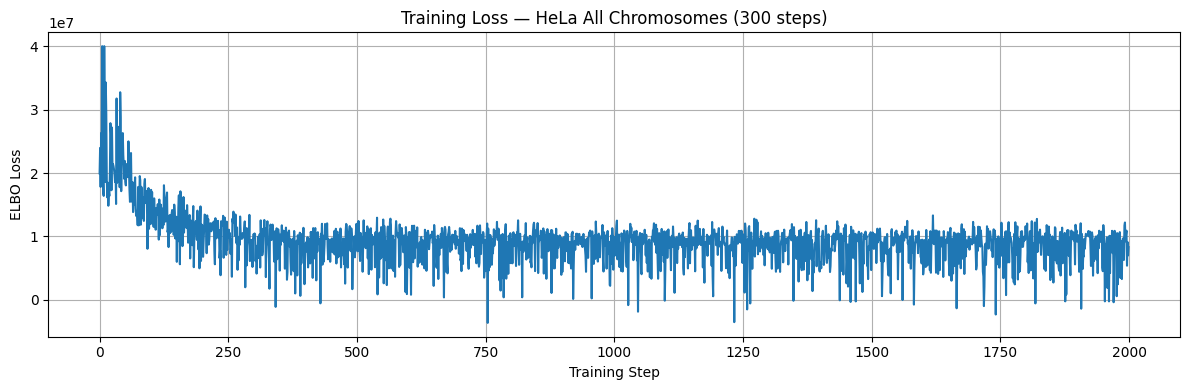

Initial loss: 19,943,498.00
Final loss:   8,313,606.50
Total drop:   11,629,891.50 (58.3%)


In [6]:
# Loss curve
plt.figure(figsize=(12, 4))
plt.plot(losses)
plt.xlabel("Training Step")
plt.ylabel("ELBO Loss")
plt.title("Training Loss — HeLa All Chromosomes (300 steps)")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_PATH, 'loss_curve_2000steps.png'), dpi=150)
plt.show()

print(f"Initial loss: {losses[0]:,.2f}")
print(f"Final loss:   {losses[-1]:,.2f}")
print(f"Total drop:   {losses[0] - losses[-1]:,.2f} ({(losses[0]-losses[-1])/losses[0]*100:.1f}%)")

In [8]:
MARK_COLS     = ['CTCF','H3K27ac','H3K27me3','H3K36me3',
                 'H3K4me1','H3K4me2','H3K4me3','H3K9ac','H4K20me1']
EFF_FEAT_COLS = ['gc_content', 'mfe_kcal', 'tm_celsius']
CONT_COL      = ['Normalized efficacy']

TEST_CHROMS       = ['chr13', 'chr21', 'chr22']
VALIDATION_CHROMS = ['chr18', 'chr20']

def load_chromosome(chrom, mask_efficacy=False):
    """
    Load one chromosome's merged CSV into tensors.

    Args:
        chrom:          e.g. 'chr11'
        mask_efficacy:  if True, set Normalized efficacy to NaN
                        (use for test/val chromosomes during evaluation)

    Returns:
        df              — the raw dataframe (for joining predictions back)
        sequences       — [1, T, 10] marks + efficacy
        eff_features    — [1, T, 3]  sequence features
        lengths         — [1]        true bin count
        true_efficacy   — Series of true values at sgRNA sites (before masking)
    """
    filepath = os.path.join(MERGED_DIR, f'HeLa_{chrom}_merged.csv')
    df = pd.read_csv(filepath)

    # Store true efficacy before any masking
    true_efficacy = df[df['Normalized efficacy'].notna()][
        ['bin_index', 'Normalized efficacy']].copy()

    if mask_efficacy:
        df['Normalized efficacy'] = np.nan

    marks  = torch.tensor(df[MARK_COLS].values,     dtype=torch.float32)
    cont   = torch.tensor(df[CONT_COL].values,      dtype=torch.float32)
    feats  = torch.tensor(df[EFF_FEAT_COLS].values,  dtype=torch.float32)
    seq    = torch.cat([marks, cont], dim=-1).unsqueeze(0)  # [1, T, 10]
    feats  = feats.unsqueeze(0)                             # [1, T, 3]
    lengths = torch.tensor([len(df)], dtype=torch.long)

    print(f"Loaded {chrom}: {len(df):,} bins, "
          f"{len(true_efficacy)} sgRNA sites")

    return df, seq, feats, lengths, true_efficacy

In [9]:
with torch.no_grad():
    w_mu_hat      = pyro.param("w_mu").detach()
    b_mu_hat      = pyro.param("b_mu").detach()
    phi_hat       = pyro.param("phi").detach()
    open_prob_hat = pyro.param("AutoDelta.probs_y").detach()
    trans_hat     = pyro.param("AutoDelta.probs_x").detach()
    init_hat      = pyro.param("AutoDelta.probs_init").detach()

print("Parameters extracted from param store")
print(f"  w_mu:      {w_mu_hat.shape}")
print(f"  open_prob: {open_prob_hat.shape}")
print(f"  trans:     {trans_hat.shape}")

Parameters extracted from param store
  w_mu:      torch.Size([11, 3])
  open_prob: torch.Size([11, 9])
  trans:     torch.Size([11, 11])


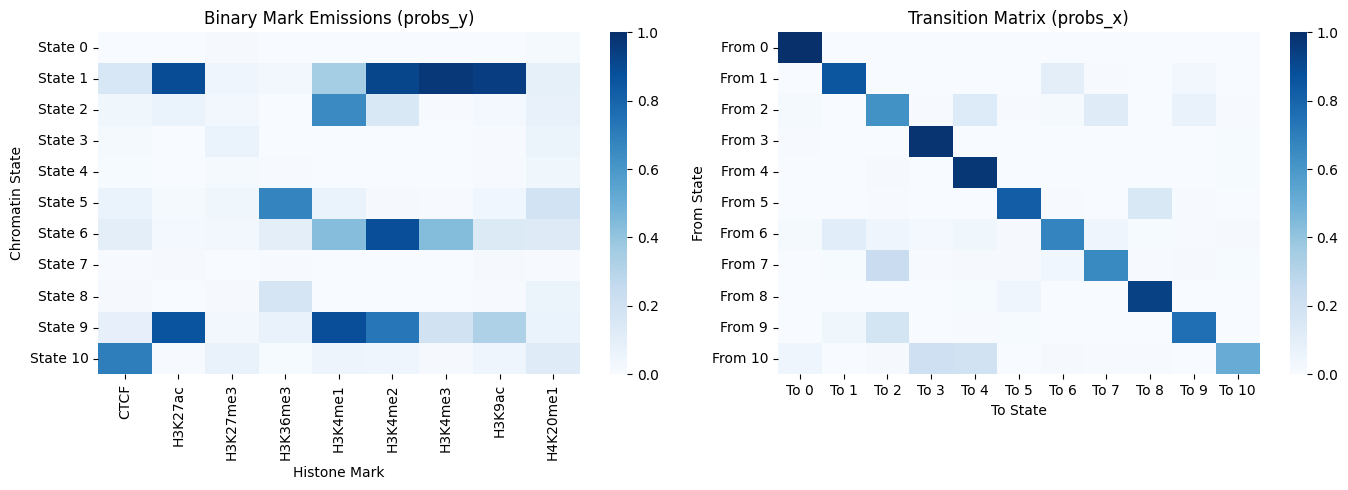

In [10]:
# Emission and transition heatmaps
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(open_prob_hat.cpu().numpy(),
            xticklabels=MARK_COLS,
            yticklabels=[f"State {i}" for i in range(args.hidden_dim)],
            vmin=0, vmax=1, cmap="Blues",
            ax=axes[0])
axes[0].set_title("Binary Mark Emissions (probs_y)")
axes[0].set_xlabel("Histone Mark")
axes[0].set_ylabel("Chromatin State")

sns.heatmap(trans_hat.cpu().numpy(),
            xticklabels=[f"To {i}" for i in range(args.hidden_dim)],
            yticklabels=[f"From {i}" for i in range(args.hidden_dim)],
            vmin=0, vmax=1, cmap="Blues",
            ax=axes[1])
axes[1].set_title("Transition Matrix (probs_x)")
axes[1].set_xlabel("To State")
axes[1].set_ylabel("From State")

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_PATH, 'emissions_and_transitions_2000steps.png'), dpi=150)
plt.show()

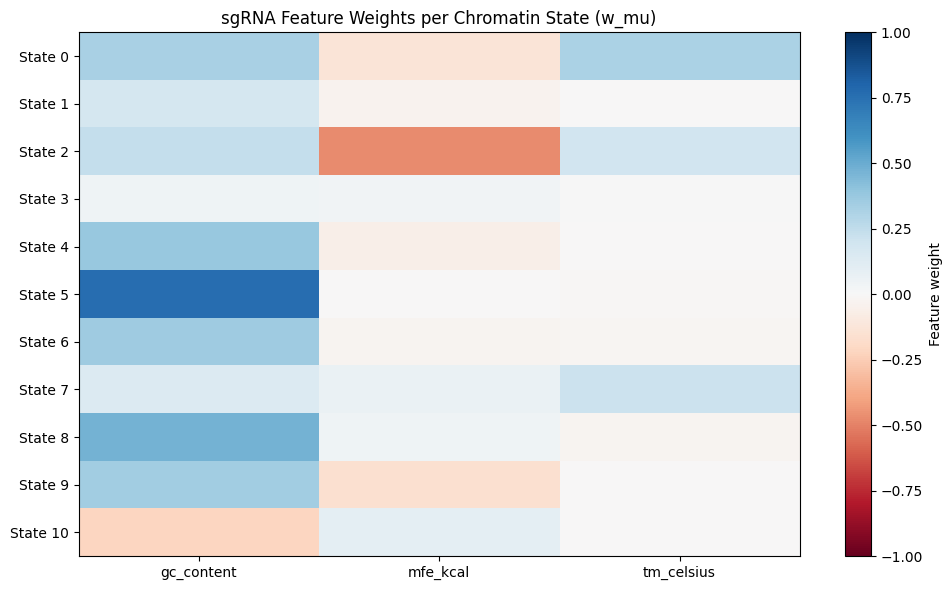

In [11]:
# Feature weights heatmap
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(w_mu_hat.detach().cpu().numpy(), cmap='RdBu', aspect='auto',
               vmin=-1, vmax=1)
ax.set_xticks(range(len(EFF_FEAT_COLS)))
ax.set_xticklabels(EFF_FEAT_COLS)
ax.set_yticks(range(args.hidden_dim))
ax.set_yticklabels([f"State {i}" for i in range(args.hidden_dim)])
plt.colorbar(im, ax=ax, label='Feature weight')
ax.set_title("sgRNA Feature Weights per Chromatin State (w_mu)")
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_PATH, 'feature_weights_2000steps.png'), dpi=150)
plt.show()

In [12]:
# ── Print model params ────────────────────────────────────────────────────────
def print_model_probs(feature_names=None):
    if feature_names is None:
        feature_names = EFF_FEAT_COLS

    print("=== Initial State Probabilities (π) ===")
    init_values = [f"{v.item():.4f}" for v in init_hat]
    print(f"  P(init states): {init_values}\n")

    print("=== Emission Parameters (Regression-based) ===")
    baseline_means = torch.sigmoid(b_mu_hat)

    for k in range(len(baseline_means)):
        label = "high efficiency" if baseline_means[k] >= 0.5 else "low efficiency"
        print(f"  State {k} ({label})")
        print(f"    Baseline CRISPR Efficiency (μ): {baseline_means[k]:.4f}")
        print(f"    Precision (φ):     {phi_hat[k]:.2f}")
        print(f"    P(open binary):    {open_prob_hat[k].tolist()}")
        weight_str = " | ".join([f"{name}: {w_mu_hat[k, i]:+.3f}"
                                 for i, name in enumerate(feature_names)])
        print(f"    Feature Weights:   [{weight_str}]")
        print("-" * 50)

    print("\n=== Transition Matrix ===")
    header = " ".join([f"To {i: <7}" for i in range(len(trans_hat))])
    print(f"            {header}")
    for k in range(len(trans_hat)):
        row = "   ".join([f"{v.item():.4f}" for v in trans_hat[k]])
        print(f"  From {k} | {row}")

print_model_probs()

=== Initial State Probabilities (π) ===
  P(init states): ['0.5028', '0.0138', '0.0388', '0.1628', '0.2050', '0.0257', '0.0013', '0.0044', '0.0413', '0.0024', '0.0016']

=== Emission Parameters (Regression-based) ===
  State 0 (low efficiency)
    Baseline CRISPR Efficiency (μ): 0.0014
    Precision (φ):     83.28
    P(open binary):    [0.0036610583774745464, 3.72343638446182e-05, 0.011979364790022373, 0.0001092995225917548, 0.00029220659052953124, 0.00024474726524204016, 0.00010020561603596434, 0.00044439922203309834, 0.016049841418862343]
    Feature Weights:   [gc_content: +0.324 | mfe_kcal: -0.132 | tm_celsius: +0.314]
--------------------------------------------------
  State 1 (low efficiency)
    Baseline CRISPR Efficiency (μ): 0.4185
    Precision (φ):     6.67
    P(open binary):    [0.15840597450733185, 0.8919196724891663, 0.05068294331431389, 0.03406433388590813, 0.35480332374572754, 0.914410412311554, 0.9676373600959778, 0.9452908039093018, 0.0878339484333992]
    Feature 

In [20]:
def viterbi(x_obs, y_obs, eff_features):
    w_mu      = pyro.param("w_mu").data
    b_mu      = pyro.param("b_mu").data
    phi       = pyro.param("phi").data
    open_prob = pyro.param("AutoDelta.probs_y").data
    trans     = pyro.param("AutoDelta.probs_x").data
    init      = pyro.param("AutoDelta.probs_init").data
    N, T      = x_obs.shape
    K         = len(init)

    eff_features  = eff_features.nan_to_num(0)
    mask          = ~torch.isnan(x_obs)
    x_obs_clean   = x_obs.nan_to_num(0.5)
    eps           = torch.finfo(x_obs.dtype).eps * 10
    x_obs_clamped = x_obs_clean.clamp(min=eps, max=1.0 - eps)

    # Dynamic Beta parameters — [N, T, K]
    logits        = torch.matmul(eff_features, w_mu.t()) + b_mu
    mu            = torch.sigmoid(logits)
    alpha_dynamic = (mu * phi).clamp(min=eps, max=1.0 - eps)
    beta_dynamic  = ((1 - mu) * phi).clamp(min=eps, max=1.0 - eps)

    # Log emissions — [N, T, K]
    lx = dist.Beta(alpha_dynamic, beta_dynamic).log_prob(
        x_obs_clamped.unsqueeze(-1))
    lx = lx * mask.unsqueeze(-1).float()
    ly = dist.Bernoulli(open_prob).log_prob(
        y_obs.unsqueeze(-2)).sum(dim=-1)
    log_emissions = lx + ly

    # Viterbi forward pass
    log_delta = torch.zeros(N, T, K, device=x_obs.device)
    psi       = torch.zeros(N, T, K, dtype=torch.long, device=x_obs.device)
    log_trans = trans.log()

    log_delta[:, 0, :] = init.log() + log_emissions[:, 0, :]

    print(f"Viterbi forward pass: T={T:,} bins, K={K} states")
    for t in range(1, T):
        if t % 50000 == 0:
            print(f"  {t:,} / {T:,} bins ({t/T*100:.1f}%)")
        prev_scores           = log_delta[:, t-1, :].unsqueeze(2)
        matrix                = prev_scores + log_trans.unsqueeze(0)
        best_scores, best_indices = matrix.max(dim=1)
        log_delta[:, t, :]    = best_scores + log_emissions[:, t, :]
        psi[:, t, :]          = best_indices

    print(f"  {T:,} / {T:,} bins (100.0%) — forward pass complete")

    # Backtrack
    print("Backtracking...")
    z_hat        = torch.zeros(N, T, dtype=torch.long, device=x_obs.device)
    z_hat[:, -1] = log_delta[:, -1, :].argmax(dim=-1)
    for t in range(T - 2, -1, -1):
        z_hat[:, t] = psi[:, t + 1, :].gather(
            1, z_hat[:, t + 1].unsqueeze(1)).squeeze(1)

    print("Backtrack complete")

    # Extract alpha/beta at most likely state per bin
    z_idx   = z_hat.unsqueeze(-1)
    z_alpha = alpha_dynamic.gather(2, z_idx).squeeze(-1)
    z_beta  = beta_dynamic.gather(2, z_idx).squeeze(-1)

    return z_hat, z_alpha, z_beta

In [21]:
def get_efficiencies_from_alpha_beta(z_alpha, z_beta):
    """
    Convert Beta distribution parameters to mean and variance.

    Args:
        z_alpha: [N, T] Beta alpha parameter at each bin
        z_beta:  [N, T] Beta beta parameter at each bin

    Returns:
        beta_mean:     [N, T] predicted efficiency (0-1)
        beta_variance: [N, T] uncertainty in prediction
    """
    beta_mean     = z_alpha / (z_alpha + z_beta)
    beta_variance = (z_alpha * z_beta / (
        torch.square(z_alpha + z_beta) * (z_alpha + z_beta + 1)))
    return beta_mean, beta_variance

In [22]:
def run_viterbi(chrom, mask_efficacy=False):
    """
    Load a chromosome, run Viterbi, and print results.

    Args:
        chrom:          e.g. 'chr17'
        mask_efficacy:  if True, hides true efficiency from model
                        (use for validation/test chromosomes)

    Returns:
        df_chrom:    raw dataframe
        seq_chrom:   [1, T, 10] tensor
        feat_chrom:  [1, T, 3] tensor
        z_hat:       [1, T] Viterbi path
        eff_means:   [1, T] predicted efficiency
        true_eff:    DataFrame of true values at sgRNA sites
    """
    df_chrom, seq_chrom, feat_chrom, len_chrom, true_eff = load_chromosome(
        chrom, mask_efficacy=mask_efficacy
    )

    with torch.no_grad():
        y_obs = seq_chrom[:, :, :9]
        x_obs = seq_chrom[:, :, 9:].squeeze(-1)

        z_hat, z_alpha, z_beta = viterbi(x_obs, y_obs, feat_chrom)
        eff_means, eff_variances = get_efficiencies_from_alpha_beta(
            z_alpha, z_beta)

        # State distribution
        print(f"\nState distribution on {chrom}:")
        for s in range(args.hidden_dim):
            count = (z_hat == s).sum().item()
            pct   = count / z_hat.numel() * 100
            print(f"  State {s}: {count:,} bins ({pct:.2f}%)")

        # Predicted efficiency at sgRNA sites only
        mask_not_nan     = ~torch.isnan(x_obs)
        eff_means_values = eff_means[mask_not_nan]
        true_values      = x_obs[mask_not_nan]

        print(f"\nPredicted efficiency at {mask_not_nan.sum().item()} sgRNA sites:")
        print(f"  Predicted mean: {eff_means_values.mean():.4f}")
        print(f"  True mean:      {true_values.mean():.4f}")

    return df_chrom, seq_chrom, feat_chrom, z_hat, eff_means, true_eff




Running Viterbi on test chromosome: chr13...
Loaded chr13: 575,849 bins, 80 sgRNA sites

DIAGNOSTIC: Learned Parameters
  b_mu (raw):      [-6.544991493225098, -0.32910770177841187, -0.3720752000808716, -1.3629372119903564, -0.9592523574829102, -0.4491341710090637, -0.1840730458498001, -0.3664301931858063, -0.5765700340270996, -0.11263260990381241, -0.553225576877594]
  b_mu (sigmoid):  ['0.0014', '0.4185', '0.4080', '0.2038', '0.2770', '0.3896', '0.4541', '0.4094', '0.3597', '0.4719', '0.3651']
  phi:             ['83.2844', '6.6670', '6.9678', '2.7394', '3.8925', '5.8377', '4.5602', '6.4563', '5.5928', '4.2296', '5.7871']
  w_mu (gc, mfe, tm):
    State  0: ['+0.3237', '-0.1315', '+0.3143']
    State  1: ['+0.1790', '-0.0319', '-0.0013']
    State  2: ['+0.2408', '-0.4725', '+0.1934']
    State  3: ['+0.0425', '+0.0382', '+0.0001']
    State  4: ['+0.3816', '-0.0557', '-0.0014']
    State  5: ['+0.7628', '-0.0036', '-0.0097']
    State  6: ['+0.3522', '-0.0311', '-0.0211']
    State 

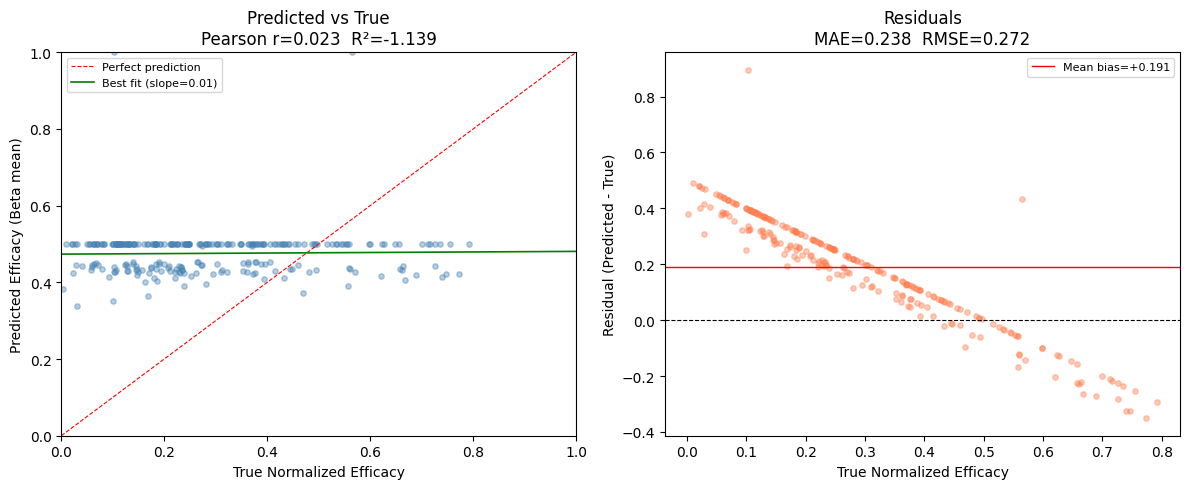


Saved results to test_evaluation_results.txt


In [19]:
# ── Full Test Set Evaluation ──────────────────────────────────────────────────
from scipy.stats import pearsonr, spearmanr, kendalltau
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np

# ── Collect predictions across all test chromosomes ───────────────────────────
all_predicted = []
all_true      = []

for chrom in TEST_CHROMS:
    print(f"Running Viterbi on test chromosome: {chrom}...")
    df_test, seq_test, feat_test, len_test, true_eff = load_chromosome(
        chrom, mask_efficacy=True
    )
    with torch.no_grad():
        y_obs = seq_test[:, :, :9]
        x_obs = seq_test[:, :, 9:].squeeze(-1)
        z_hat_test, z_alpha_test, z_beta_test = viterbi(x_obs, y_obs, feat_test)
        eff_means_test, eff_var_test = get_efficiencies_from_alpha_beta(
            z_alpha_test, z_beta_test)

        sgrna_indices = torch.tensor(
            true_eff['bin_index'].values, dtype=torch.long)
        predicted = eff_means_test[0, sgrna_indices].cpu().numpy()
        true_vals = true_eff['Normalized efficacy'].values

        # ── Logit diagnostics at sgRNA sites ─────────────────────────────────
        w_mu = pyro.param("w_mu").data
        b_mu = pyro.param("b_mu").data

        sgrna_feats     = feat_test[0, sgrna_indices]          # [n_sgrna, 3]
        feat_contrib    = torch.matmul(sgrna_feats, w_mu.t())  # [n_sgrna, K]
        logits          = feat_contrib + b_mu                  # [n_sgrna, K]
        mu_sgrna        = torch.sigmoid(logits)                # [n_sgrna, K]
        assigned_states = z_hat_test[0, sgrna_indices]         # [n_sgrna]

        print(f"\n--- Logit diagnostics for {chrom} ---")
        print(f"Feature stats at sgRNA sites:")
        for fi, fname in enumerate(["gc_content", "mfe_kcal", "tm_celsius"]):
            vals = sgrna_feats[:, fi]
            print(f"  {fname:12s}: mean={vals.mean():.4f}  std={vals.std():.4f}  "
                  f"min={vals.min():.4f}  max={vals.max():.4f}")

        print(f"\nPer-state logits and mu at sgRNA sites:")
        for s in range(11):
            fc = feat_contrib[:, s]
            print(f"  State {s:2d}: b_mu={b_mu[s]:+.4f}  feat_contrib mean={fc.mean():+.4f}  "
                  f"std={fc.std():.4f}  total_logit mean={logits[:,s].mean():+.4f}  "
                  f"mu={mu_sgrna[:,s].mean():.4f}")

        print(f"\nState assignments at sgRNA sites:")
        for s in range(11):
            cnt = (assigned_states == s).sum().item()
            pct = cnt / len(sgrna_indices) * 100
            if cnt > 0:
                mu_assigned = mu_sgrna[assigned_states == s, s]
                print(f"  State {s:2d}: {cnt:3d} sites ({pct:5.1f}%)  "
                      f"mu_mean={mu_assigned.mean():.4f}")
            else:
                print(f"  State {s:2d}:   0 sites (  0.0%)")

        print(f"\nPredicted vs true at sgRNA sites:")
        print(f"  Predicted mean={predicted.mean():.4f}  std={predicted.std():.4f}")
        print(f"  True      mean={true_vals.mean():.4f}  std={true_vals.std():.4f}")

    assert len(predicted) == len(true_vals), \
        f"{chrom}: {len(predicted)} predicted vs {len(true_vals)} true"

    all_predicted.extend(predicted.tolist())
    all_true.extend(true_vals.tolist())
    print(f"  {chrom}: {len(predicted)} predicted, {len(true_vals)} ground truth sites")

all_predicted = np.array(all_predicted)
all_true      = np.array(all_true)

# ── Correlation ───────────────────────────────────────────────────────────────
r,   _  = pearsonr(all_predicted, all_true)
rho, _  = spearmanr(all_predicted, all_true)
tau, _  = kendalltau(all_predicted, all_true)

# ── R² ────────────────────────────────────────────────────────────────────────
r_sq_pearson = r ** 2
ss_res       = np.sum((all_true - all_predicted) ** 2)
ss_tot       = np.sum((all_true - all_true.mean()) ** 2)
r_sq_true    = 1 - (ss_res / ss_tot)

# ── Error metrics ─────────────────────────────────────────────────────────────
mae  = np.abs(all_predicted - all_true).mean()
rmse = np.sqrt(((all_predicted - all_true) ** 2).mean())
bias = (all_predicted - all_true).mean()

# ── Classification (top 30% = high efficiency) ───────────────────────────────
threshold   = np.percentile(all_true, 70)
true_binary = (all_true      >= threshold).astype(int)
auc_roc     = roc_auc_score(true_binary, all_predicted)
auc_pr      = average_precision_score(true_binary, all_predicted)

# ── Print results ─────────────────────────────────────────────────────────────
print(f"\n{'='*50}")
print(f"=== Test Set Evaluation (n={len(all_true)}) ===")
print(f"    Chromosomes: {TEST_CHROMS}")
print(f"\nCorrelation:")
print(f"  Pearson r:          {r:+.3f}")
print(f"  Spearman ρ:         {rho:+.3f}")
print(f"  Kendall τ:          {tau:+.3f}")
print(f"\nVariance explained:")
print(f"  r² (from Pearson):  {r_sq_pearson:.3f}")
print(f"  R² (true):          {r_sq_true:.3f}")
print(f"\nError metrics:")
print(f"  MAE:                {mae:.4f}")
print(f"  RMSE:               {rmse:.4f}")
print(f"  Mean bias:          {bias:+.4f}  (+ = overpredicts, - = underpredicts)")
print(f"\nClassification (top 30% threshold={threshold:.3f}):")
print(f"  AUC-ROC:            {auc_roc:.3f}")
print(f"  AUC-PR:             {auc_pr:.3f}")

# ── Scatter plot ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(all_true, all_predicted, alpha=0.4, s=15, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=0.8, label='Perfect prediction')
m, b_fit = np.polyfit(all_true, all_predicted, 1)
x_line   = np.linspace(0, 1, 100)
axes[0].plot(x_line, m * x_line + b_fit, 'g-',
             linewidth=1.2, label=f'Best fit (slope={m:.2f})')
axes[0].set_xlabel("True Normalized Efficacy")
axes[0].set_ylabel("Predicted Efficacy (Beta mean)")
axes[0].set_title(f"Predicted vs True\nPearson r={r:.3f}  R²={r_sq_true:.3f}")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)

residuals = all_predicted - all_true
axes[1].scatter(all_true, residuals, alpha=0.4, s=15, color='coral')
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].axhline(bias, color='red', linewidth=1.0,
                linestyle='-', label=f'Mean bias={bias:+.3f}')
axes[1].set_xlabel("True Normalized Efficacy")
axes[1].set_ylabel("Residual (Predicted - True)")
axes[1].set_title(f"Residuals\nMAE={mae:.3f}  RMSE={rmse:.3f}")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_PATH, 'test_set_evaluation.png'), dpi=150)
plt.show()

# ── Save results to text file ─────────────────────────────────────────────────
results_text = f"""Test Set Evaluation
Chromosomes: {TEST_CHROMS}
N: {len(all_true)}

Correlation:
  Pearson r:         {r:+.3f}
  Spearman rho:      {rho:+.3f}
  Kendall tau:       {tau:+.3f}

Variance explained:
  r² (from Pearson): {r_sq_pearson:.3f}
  R² (true):         {r_sq_true:.3f}

Error metrics:
  MAE:               {mae:.4f}
  RMSE:              {rmse:.4f}
  Mean bias:         {bias:+.4f}

Classification (top 30% threshold={threshold:.3f}):
  AUC-ROC:           {auc_roc:.3f}
  AUC-PR:            {auc_pr:.3f}
"""

with open(os.path.join(DRIVE_PATH, 'test_evaluation_results.txt'), 'w') as f:
    f.write(results_text)
print(f"\nSaved results to test_evaluation_results.txt")

In [ ]:
# Reordering states by "total emissions activity"
# Calculate a 'score' for each state (e.g., sum of all probabilities)
# This acts as a proxy for 'total activity'
def min_max(t):
    return (t - t.min()) / (t.max() - t.min() + 1e-6)

with torch.no_grad():
    # Scale both to [0, 1] across the K states
    score_chromatin = min_max(open_prob_hat.sum(dim=-1))
    score_meth = min_max(torch.sigmoid(b_mu_hat))  # Using b_mu without features as baseline
    # Now they have equal "voting power" in the sort
    state_activity = score_chromatin + score_meth
    print(f"Old emission probs: {pyro.param("AutoDelta.probs_y")}")
    print(f"state activity: {state_activity}")

    # Get the indices that sort from most active to least active
    sort_indices = torch.argsort(state_activity, descending=True)
    print(f"sort_indices {sort_indices}")

    # Reorder all learned parameters by "activity"
    w_mu_hat = w_mu_hat.clone()[sort_indices]
    b_mu_hat = b_mu_hat.clone()[sort_indices]
    phi_hat = phi_hat.clone()[sort_indices]
    open_prob_hat = open_prob_hat.clone()[sort_indices]
    # Reordering the transition matrix requires swapping rows AND columns
    trans_hat = trans_hat.clone()[sort_indices][:, sort_indices]
    init_hat = init_hat.clone()[sort_indices]

    # Updating model with reordering
    param_store = pyro.get_param_store()
    param_store["w_mu"] = w_mu_hat
    param_store["b_mu"] = b_mu_hat
    param_store["phi"] = phi_hat
    param_store["AutoDelta.probs_y"] = open_prob_hat
    param_store["AutoDelta.probs_x"] = trans_hat
    param_store["AutoDelta.probs_init"] = init_hat

    print(f"New emission probs: {pyro.param("AutoDelta.probs_y")}")

Old emission probs: tensor([[1.3194e-05, 5.3655e-03, 2.9380e-04, 2.0443e-03, 1.6289e-03, 1.3764e-04,
         1.4640e-02, 6.6155e-04, 4.8402e-04],
        [3.9828e-04, 3.4883e-01, 9.3050e-03, 8.9588e-02, 4.4318e-01, 7.1740e-01,
         1.1654e-01, 2.5184e-01, 5.5509e-02],
        [7.1180e-03, 3.1095e-05, 1.8482e-05, 1.1031e-08, 1.5402e-02, 1.0315e-04,
         4.5570e-04, 2.4910e-05, 3.8156e-05],
        [3.2040e-02, 8.5281e-04, 5.7468e-03, 1.7037e-03, 9.6639e-08, 3.4503e-04,
         1.3684e-03, 6.2936e-03, 6.8770e-02],
        [1.5943e-02, 1.9154e-03, 2.6740e-02, 5.6095e-03, 6.4897e-04, 3.2878e-09,
         1.7222e-06, 8.4202e-05, 3.4765e-02],
        [4.8181e-02, 5.5162e-03, 9.7312e-03, 4.3734e-01, 5.7967e-03, 3.9522e-03,
         5.9654e-04, 1.7405e-02, 1.1230e-01],
        [4.6568e-01, 1.1887e-02, 3.5675e-03, 4.3816e-02, 1.4010e-02, 6.4701e-01,
         5.3957e-01, 1.2697e-01, 4.3566e-02],
        [1.0113e-02, 9.7550e-04, 2.4989e-04, 2.3112e-04, 3.7074e-05, 1.3388e-07,
         5

In [ ]:
# ChromHMM reordering by Pearson correlation of emission params
# Only using probs_y (binary mark emissions), not efficiencies
# d(x,y) = \sqrt{(1-\rho(p_x,p_y))}, p_x: state x emission params

def get_emission_profiles():
    # Extract only the learned Bernoulli probabilities
    # Shape: [num_states, num_bin_features] (e.g., [4, 2])

    profiles = open_prob_hat

    # If also using efficiency emissions, need to concatenate Beta fingerprint
    # base_meth = torch.sigmoid(b_mu_hat).unsqueeze(-1)
    #profiles = torch.cat([open_prob_hat, base_meth, w_mu_hat], dim=-1)

    return profiles

def reorder_states_greedy(profiles):
    num_states = profiles.shape[0]

    # 1. Compute Distance Matrix based on Pearson Correlation
    # d(x,y) = sqrt(1 - Pearson(px, py))
    # rho = cov / (stds + 1e-8)
    centered = profiles - profiles.mean(dim=1, keepdim=True)
    norm = torch.norm(centered, dim=1, keepdim=True)
    corr = (centered @ centered.t()) / (norm @ norm.t() + 1e-8)
    dist_matrix = torch.sqrt(torch.clamp(1.0 - corr, min=0))

    best_order = []
    min_total_dist = float('inf')

    # 2. Try each state as the starting point
    for start_node in range(num_states):
        current_order = [start_node]
        unselected = list(set(range(num_states)) - {start_node})
        total_dist = 0.0

        current_node = start_node
        while unselected:
            # Find the nearest unselected neighbor
            distances = dist_matrix[current_node, unselected]
            nearest_idx = torch.argmin(distances).item()
            nearest_node = unselected.pop(nearest_idx)

            total_dist += dist_matrix[current_node, nearest_node].item()
            current_order.append(nearest_node)
            current_node = nearest_node

        if total_dist < min_total_dist:
            min_total_dist = total_dist
            best_order = current_order

    return best_order

In [ ]:
with torch.no_grad():
    greedy_order = reorder_states_greedy(get_emission_profiles())
    print(f"greedy_order: {greedy_order}")

    # Reorder all learned parameters by greedy order
    w_mu_hat = w_mu_hat.clone()[greedy_order]
    b_mu_hat = b_mu_hat.clone()[greedy_order]
    phi_hat = phi_hat.clone()[greedy_order]
    open_prob_hat = open_prob_hat.clone()[greedy_order]
    # Reordering the transition matrix requires swapping rows AND columns
    trans_hat = trans_hat.clone()[greedy_order][:, greedy_order]
    init_hat = init_hat.clone()[greedy_order]

    # Updating model with reordering
    param_store = pyro.get_param_store()
    param_store["w_mu"] = w_mu_hat
    param_store["b_mu"] = b_mu_hat
    param_store["phi"] = phi_hat
    param_store["AutoDelta.probs_y"] = open_prob_hat
    param_store["AutoDelta.probs_x"] = trans_hat
    param_store["AutoDelta.probs_init"] = init_hat

    print(f"New emission probs: {pyro.param("AutoDelta.probs_y")}")

greedy_order: [10, 0, 1, 2, 7, 6, 3, 8, 5, 9, 4]
New emission probs: tensor([[1.3194e-05, 5.3655e-03, 2.9380e-04, 2.0443e-03, 1.6289e-03, 1.3764e-04,
         1.4640e-02, 6.6155e-04, 4.8402e-04],
        [4.6568e-01, 1.1887e-02, 3.5675e-03, 4.3816e-02, 1.4010e-02, 6.4701e-01,
         5.3957e-01, 1.2697e-01, 4.3566e-02],
        [3.9828e-04, 3.4883e-01, 9.3050e-03, 8.9588e-02, 4.4318e-01, 7.1740e-01,
         1.1654e-01, 2.5184e-01, 5.5509e-02],
        [5.5630e-02, 3.6523e-02, 1.6000e-03, 2.3290e-02, 4.3138e-01, 1.4246e-05,
         2.2471e-03, 1.0625e-02, 2.0786e-02],
        [7.1180e-03, 3.1095e-05, 1.8482e-05, 1.1031e-08, 1.5402e-02, 1.0315e-04,
         4.5570e-04, 2.4910e-05, 3.8156e-05],
        [5.2103e-02, 2.3048e-03, 1.6425e-02, 4.0901e-02, 4.8419e-02, 1.9001e-05,
         6.0550e-03, 7.7611e-02, 4.7832e-02],
        [1.0113e-02, 9.7550e-04, 2.4989e-04, 2.3112e-04, 3.7074e-05, 1.3388e-07,
         5.5111e-07, 8.5695e-03, 4.2611e-03],
        [3.2040e-02, 8.5281e-04, 5.7468e-0